# Draw Policy — determinized lookahead

Here we determinize worlds, taking whichever draw decision has the higher EV.

In [ ]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
sys.path.insert(0, os.path.abspath('../..'))          # repo root from notebooks/policy/

from agent.cards import Card, make_deck
from agent.inference import BeliefState
from agent.policy import draw_values, DetDrawPolicy
from agent.eval.harness import run_match, _play_indexed, _points_to

RNG = np.random.default_rng(0)


## 1. Setup

- We Madow-sample worlds and roll each draw option to a terminal score with the engine-faithful base playout.
- We pair take vs stock branches on the same worlds.


In [2]:
# Sanity: opponent visibly collects hearts (took 4H). 9H extends our 7H8H run and
# sits outside their low-heart window -- a tempting take. The determinized values
# weigh that against the stock lottery on the same sampled worlds.
hand = [Card('7','H'), Card('8','H'), Card('2','C'), Card('5','D'), Card('9','C'),
        Card('K','S'), Card('Q','D'), Card('4','S'), Card('J','H'), Card('3','C')]
bs = BeliefState(list(hand), Card('4','H'))
bs.observe_opponent_draw_discard_bayesian(Card('4','H'), nu=3.0)
top = Card('9','H')
vt, vs = draw_values(hand, top, bs, n_det=300, rng=np.random.default_rng(1))
print(f'V_take(9H) = {vt:+.2f}   V_stock = {vs:+.2f}   -> {"TAKE 9H" if vt >= vs else "DRAW stock"}')


V_take(9H) = -3.10   V_stock = -13.18   -> TAKE 9H


## 2. Does the lookahead beat the one-ply rule?

The decisive test: paired points per hand for `prob_detdraw` vs the standard probabilistic agent, on identical deals.


/Users/charliecockerell/Documents/Codex/probabilistic-rummy/.venv/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


determinized draw - one-ply baseline: -6.12 pts/hand  +/-1.36 SE  (n=200)


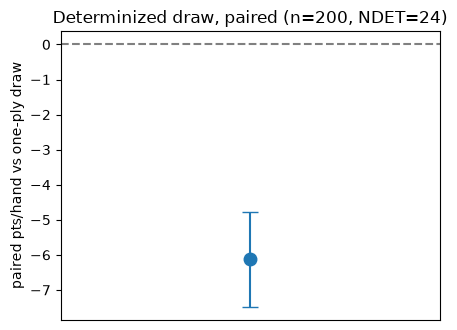

In [3]:
def margins(subject_kind, n, ks=150, seed0=0, params=None, n_jobs=-1):
    """Signed points/hand for `subject_kind` (seat 0) vs the probabilistic baseline,
    one per deal; shared seeds -> identical deals (paired). n_jobs=-1 fans the deals
    across all cores -- results are seed-identical to serial."""
    p = {'knock_samples': ks}
    if params: p.update(params)
    opp = ('probabilistic', {'knock_samples': ks})
    res = Parallel(n_jobs=n_jobs)(
        delayed(_play_indexed)((subject_kind, p), opp, seed0 + i, 0) for i in range(n))
    return np.array([_points_to(r, 0) for r in res])

N_PAIR, KS, NDET = 200, 150, 24
ref = margins('probabilistic', N_PAIR, KS)
det = margins('prob_detdraw',  N_PAIR, KS, params={'n_det': NDET})
d = det - ref
m, se = d.mean(), d.std(ddof=1) / np.sqrt(N_PAIR)
print(f'determinized draw - one-ply baseline: {m:+.2f} pts/hand  +/-{se:.2f} SE  (n={N_PAIR})')

fig, ax = plt.subplots(figsize=(4.6, 3.4))
ax.errorbar([0], [m], yerr=[se], fmt='o', ms=9, capsize=6)
ax.axhline(0, ls='--', color='grey')
ax.set_xticks([]); ax.set_ylabel('paired pts/hand vs one-ply draw')
ax.set_title(f'Determinized draw, paired (n={N_PAIR}, NDET={NDET})')
plt.tight_layout(); plt.show()


## 3. Does any edge survive outside self-play?

Win rate vs greedy and vs the probabilistic baseline (the agent it's trying to improve on), each with a ±1 SE bar against parity.


detdraw vs greedy        win=0.445 +/-0.035  margin=-2.12
detdraw vs probabilistic win=0.410 +/-0.035  margin=-4.37


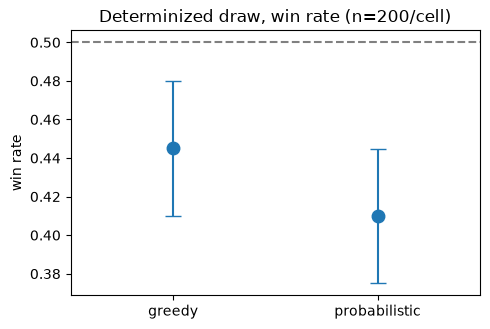

In [4]:
N_GAMES, KS, NDET, N_JOBS = 200, 150, 24, -1
res = {}
for opp in ('greedy', 'probabilistic'):
    opp_params = {'knock_samples': KS} if opp == 'probabilistic' else {}
    r = run_match(('prob_detdraw', {'n_det': NDET, 'knock_samples': KS}),
                  (opp, opp_params), n_games=N_GAMES, base_seed=0,
                  alternate_seats=True, n_jobs=N_JOBS)
    p = r['win_rate']; res[opp] = (p, (p * (1 - p) / N_GAMES) ** 0.5, r['avg_score_margin'])
    print(f'detdraw vs {opp:13} win={p:.3f} +/-{res[opp][1]:.3f}  margin={r["avg_score_margin"]:+.2f}')

fig, ax = plt.subplots(figsize=(5, 3.4))
xs = list(range(len(res)))
ax.errorbar(xs, [res[o][0] for o in res], yerr=[res[o][1] for o in res],
            fmt='o', ms=9, capsize=6)
ax.axhline(0.5, ls='--', color='grey')
ax.set_xticks(xs); ax.set_xticklabels(list(res)); ax.set_xlim(-0.5, len(res) - 0.5)
ax.set_ylabel('win rate'); ax.set_title(f'Determinized draw, win rate (n={N_GAMES}/cell)')
plt.tight_layout(); plt.show()


## Summary

This was meant to replace the one-ply closed-form draw (and its inert `gamma` leak penalty) with a determinized lookahead. However, the models in this policy suffer from a few simple failings.

- The base policy is too naive; against any good player, continuing the simulation with a weak one gives us a misleading expected value.
- Simulation is too computationally expensive; even when a better player was implemented in `search_policy`, parity remained. The many simulations are a bottleneck for further research, e.g. ML.

For my purposes, the one-ply policy is the ceiling, now confirmed from four directions — knock (optimal-stopping), discard (search / search_smart), draw (this notebook), and the parameters (alpha / kappa / gamma). Given the belief, the action rule is already near-optimal.